In [ ]:
### check wireline log inventory from force 2020 competition dataset

In [5]:
### imports
import os
from pathlib import Path

import lasio
import numpy as np
import pandas as pd

import random

In [2]:

cwd = Path.cwd()
project_dir = cwd.parent
data_root_dir = project_dir.parent / "data"

def list_contents(dir):
    print(f'\nELEMENTS IN /{os.path.basename(dir)}/:')
    print(f'{sorted(path.name for path in dir.iterdir())}')

list_contents(project_dir)
list_contents(data_root_dir)


ELEMENTS IN /force_2020_well_log_analysis/:
['.DS_Store', '.git', '.venv', '.vscode', 'README.md', 'notebooks']

ELEMENTS IN /data/:
['.DS_Store', 'force_2020_well_log_analysis']


In [3]:
data_dir = data_root_dir / 'force_2020_well_log_analysis' / 'Force_2020_all_wells'

LAS_FILES = sorted(data_dir.glob("*.las"))
print(f"LAS files found: {len(LAS_FILES)}")

list_contents(data_dir)

LAS files found: 118

ELEMENTS IN /Force_2020_all_wells/:
['15_9-13.las', '15_9-14.las', '15_9-15.las', '15_9-17.las', '15_9-23.las', '16_1-2.las', '16_1-6 A.las', '16_10-1.las', '16_10-2.las', '16_10-3.las', '16_10-5.las', '16_11-1 ST3.las', '16_2-11 A.las', '16_2-16.las', '16_2-6.las', '16_2-7.las', '16_4-1.las', '16_5-3.las', '16_7-4.las', '16_7-5.las', '16_7-6.las', '16_8-1.las', '17_11-1.las', '17_4-1.las', '25_10-10.las', '25_10-9.las', '25_11-15.las', '25_11-19 S.las', '25_11-24.las', '25_11-5.las', '25_2-13 T4.las', '25_2-14.las', '25_2-7.las', '25_3-1.las', '25_4-5.las', '25_5-1.las', '25_5-3.las', '25_5-4.las', '25_6-1.las', '25_6-2.las', '25_6-3.las', '25_7-2.las', '25_8-5 S.las', '25_8-7.las', '25_9-1.las', '26_4-1.las', '29_3-1.las', '29_6-1.las', '30_3-3.las', '30_3-5 S.las', '30_6-5.las', '31_2-1.las', '31_2-10.las', '31_2-19 S.las', '31_2-21 S.las', '31_2-7.las', '31_2-8.las', '31_2-9.las', '31_3-1.las', '31_3-2.las', '31_3-3.las', '31_3-4.las', '31_4-10.las', '31_4-5.l

In [7]:
### inspect random las file

random_las = random.choice(LAS_FILES)
print(f'{random_las.name}\n')
### verbose output
single_las = lasio.read(random_las)
print(single_las)
### selected output
for item in single_las.well:
    print(
        item.mnemonic,
        "=",
        item.value,
        item.unit,
        "|",
        item.descr,
    )

35_3-7 S.las

STRT = 282.09185136 m | 
STOP = 4052.0112305 m | 
STEP = 0.152 m | 
NULL = -999.25  | 
COMP =   | COMPANY
WELL = 35/3-7 S  | WELL
FLD =   | FIELD
LOC =   | LOCATION
SRVC =   | SERVICE COMPANY
DATE = 2020-08-09 20:02:03   : Log Export Date {yyyy-MM-dd HH:mm  | ss}
PROV =   | PROVINCE
UWI = 35/3-7 S  | UNIQUE WELL ID
API =   | API NUMBER


In [8]:
### get header values

def get_header_value(las, mnemonic):
    try:
        return las.well[mnemonic].value
    except (KeyError, AttributeError):
        return np.nan


well_records = []
curve_records = []

In [9]:
### iterate over each of 118 wells and get header values, curves and statistics

for path in LAS_FILES:
    try:
        ### get las file path
        las = lasio.read(path)
        df = las.df()

        depth = pd.to_numeric(
            pd.Series(df.index),
            errors="coerce",
        ).dropna().to_numpy()

        depth_difference = np.diff(depth)

        ### get mnemonic header value nd statistics
        well_name = get_header_value(las, "WELL")
        if pd.isna(well_name) or str(well_name).strip() == "":
            well_name = path.stem

        well_records.append(
            {
                "file": path.name,
                "well": str(well_name),
                "samples": len(df),
                "curves": len(df.columns),
                "depth_min": np.nanmin(depth) if len(depth) else np.nan,
                "depth_max": np.nanmax(depth) if len(depth) else np.nan,
                "median_step": (
                    np.nanmedian(np.abs(depth_difference))
                    if len(depth_difference)
                    else np.nan
                ),
                "duplicate_depths": int(df.index.duplicated().sum()),
                "depth_monotonic": bool(
                    np.all(depth_difference > 0)
                    or np.all(depth_difference < 0)
                ),
                "read_error": None,
            }
        )
        
        ### get individual curves and statistics
        for curve in las.curves[1:]:
            mnemonic = curve.mnemonic
            series = (
                pd.to_numeric(df[mnemonic], errors="coerce")
                if mnemonic in df.columns
                else pd.Series(dtype=float)
            )

            curve_records.append(
                {
                    "file": path.name,
                    "well": str(well_name),
                    "curve": mnemonic,
                    "unit": curve.unit,
                    "description": curve.descr,
                    "samples": len(series),
                    "valid_samples": int(series.notna().sum()),
                    "missing_pct": float(series.isna().mean() * 100),
                }
            )

    except Exception as error:
        well_records.append(
            {
                "file": path.name,
                "well": path.stem,
                "samples": np.nan,
                "curves": np.nan,
                "depth_min": np.nan,
                "depth_max": np.nan,
                "median_step": np.nan,
                "duplicate_depths": np.nan,
                "depth_monotonic": np.nan,
                "read_error": str(error),
            }
        )

### create pandas df of the well and curve records
well_inventory = pd.DataFrame(well_records)
curve_inventory = pd.DataFrame(curve_records)


In [12]:
### curve presence

curve_presence = (
    curve_inventory
    .assign(present=True)
    .pivot_table(
        index="well",
        columns="curve",
        values="present",
        aggfunc="any",
        fill_value=False,
    )
    .astype(bool)
)


In [13]:
### curve availability accross wells

curve_availability = (
    curve_presence
    .sum()
    .sort_values(ascending=False)
    .rename("wells")
    .to_frame()
)

curve_availability["percentage"] = (
    curve_availability["wells"]
    / len(curve_presence)
    * 100
)

In [10]:
well_inventory

,file,well,samples,curves,depth_min,depth_max,median_step,duplicate_depths,depth_monotonic,read_error
0,15_9-13.las,15/9-13 Sleipner East Appr,21441,20,25.000000,3283.880000,0.152,0,True,None
1,15_9-14.las,15/9-14,22875,20,98.804001,3575.652001,0.152,0,True,None
2,15_9-15.las,15/9-15 Gungne,20954,22,25.000000,3209.856000,0.152,0,True,None
3,15_9-17.las,15/9-17,19879,21,102.613998,3124.069998,0.152,0,True,None
4,15_9-23.las,15/9-23 Skardkollen,20494,20,110.000000,3224.936000,0.152,0,True,None
...,...,...,...,...,...,...,...,...,...,...
113,35_9-7.las,35/9-7,17166,20,397.050800,3006.130800,0.152,0,True,None
114,35_9-8.las,35/9-8,18842,20,392.021600,3255.853600,0.152,0,True,None
115,36_7-3.las,36/7-3,16950,16,373.000000,2949.248000,0.152,0,True,None
116,7_1-1.las,7/1-1,17982,20,82.600800,2815.712800,0.152,0,True,None


In [11]:
curve_inventory

,file,well,curve,unit,description,samples,valid_samples,missing_pct
0,15_9-13.las,15/9-13 Sleipner East Appr,FORCE_2020_LITHOFACIES_CONFIDENCE,_,FORCE_2020_LITHOFACIES_CONFIDENCE,21441,18277,14.756774
1,15_9-13.las,15/9-13 Sleipner East Appr,FORCE_2020_LITHOFACIES_LITHOLOGY,_,FORCE_2020_LITHOFACIES_LITHOLOGY,21441,18270,14.789422
2,15_9-13.las,15/9-13 Sleipner East Appr,CALI,in,CALI,21441,18345,14.439625
3,15_9-13.las,15/9-13 Sleipner East Appr,MUDWEIGHT,_,MUDWEIGHT,21441,17520,18.287393
4,15_9-13.las,15/9-13 Sleipner East Appr,ROP,m/h,ROP,21441,20297,5.335572
...,...,...,...,...,...,...,...,...
2270,7_1-2 S.las,7/1-2 S,DRHO,g/cm3,DRHO,19586,1617,91.744103
2271,7_1-2 S.las,7/1-2 S,DEPTH_MD,_,DEPTH_MD,19586,19544,0.214439
2272,7_1-2 S.las,7/1-2 S,X_LOC,_,x_loc,19586,19544,0.214439
2273,7_1-2 S.las,7/1-2 S,Y_LOC,_,y_loc,19586,19544,0.214439


In [15]:
curve_presence

curve,BS,CALI,DCAL,DEPTH_MD,DRHO,DTC,DTS,FORCE_2020_LITHOFACIES_CONFIDENCE,FORCE_2020_LITHOFACIES_LITHOLOGY,GR,...,RMIC,ROP,ROPA,RSHA,RXO,SGR,SP,X_LOC,Y_LOC,Z_LOC
well,,,,,,,,,,,,,,,,,,,,,
15/9-13 Sleipner East Appr,False,True,False,True,True,True,False,True,True,True,...,False,True,False,True,True,False,True,True,True,True
15/9-14,False,True,False,True,True,True,False,True,True,True,...,False,True,False,True,True,False,True,True,True,True
15/9-15 Gungne,True,True,True,True,True,True,False,True,True,True,...,False,True,False,True,True,False,True,True,True,True
15/9-17,False,True,False,True,True,True,False,True,True,True,...,False,True,False,True,True,True,True,True,True,True
15/9-23 Skardkollen,True,True,True,True,True,True,True,True,True,True,...,False,True,True,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35/9-7,True,True,False,True,True,True,True,True,True,True,...,True,True,True,False,False,False,False,True,True,True
35/9-8,True,True,False,True,True,True,True,True,True,True,...,True,True,True,False,False,False,False,True,True,True
36/7-3,False,True,False,True,True,True,False,True,True,True,...,False,False,True,False,False,False,False,True,True,True


In [16]:
curve_availability

,wells,percentage
curve,,
RDEP,118,100.000000
FORCE_2020_LITHOFACIES_LITHOLOGY,118,100.000000
Y_LOC,118,100.000000
X_LOC,118,100.000000
RHOB,118,100.000000
CALI,118,100.000000
NPHI,118,100.000000
GR,118,100.000000
Z_LOC,118,100.000000


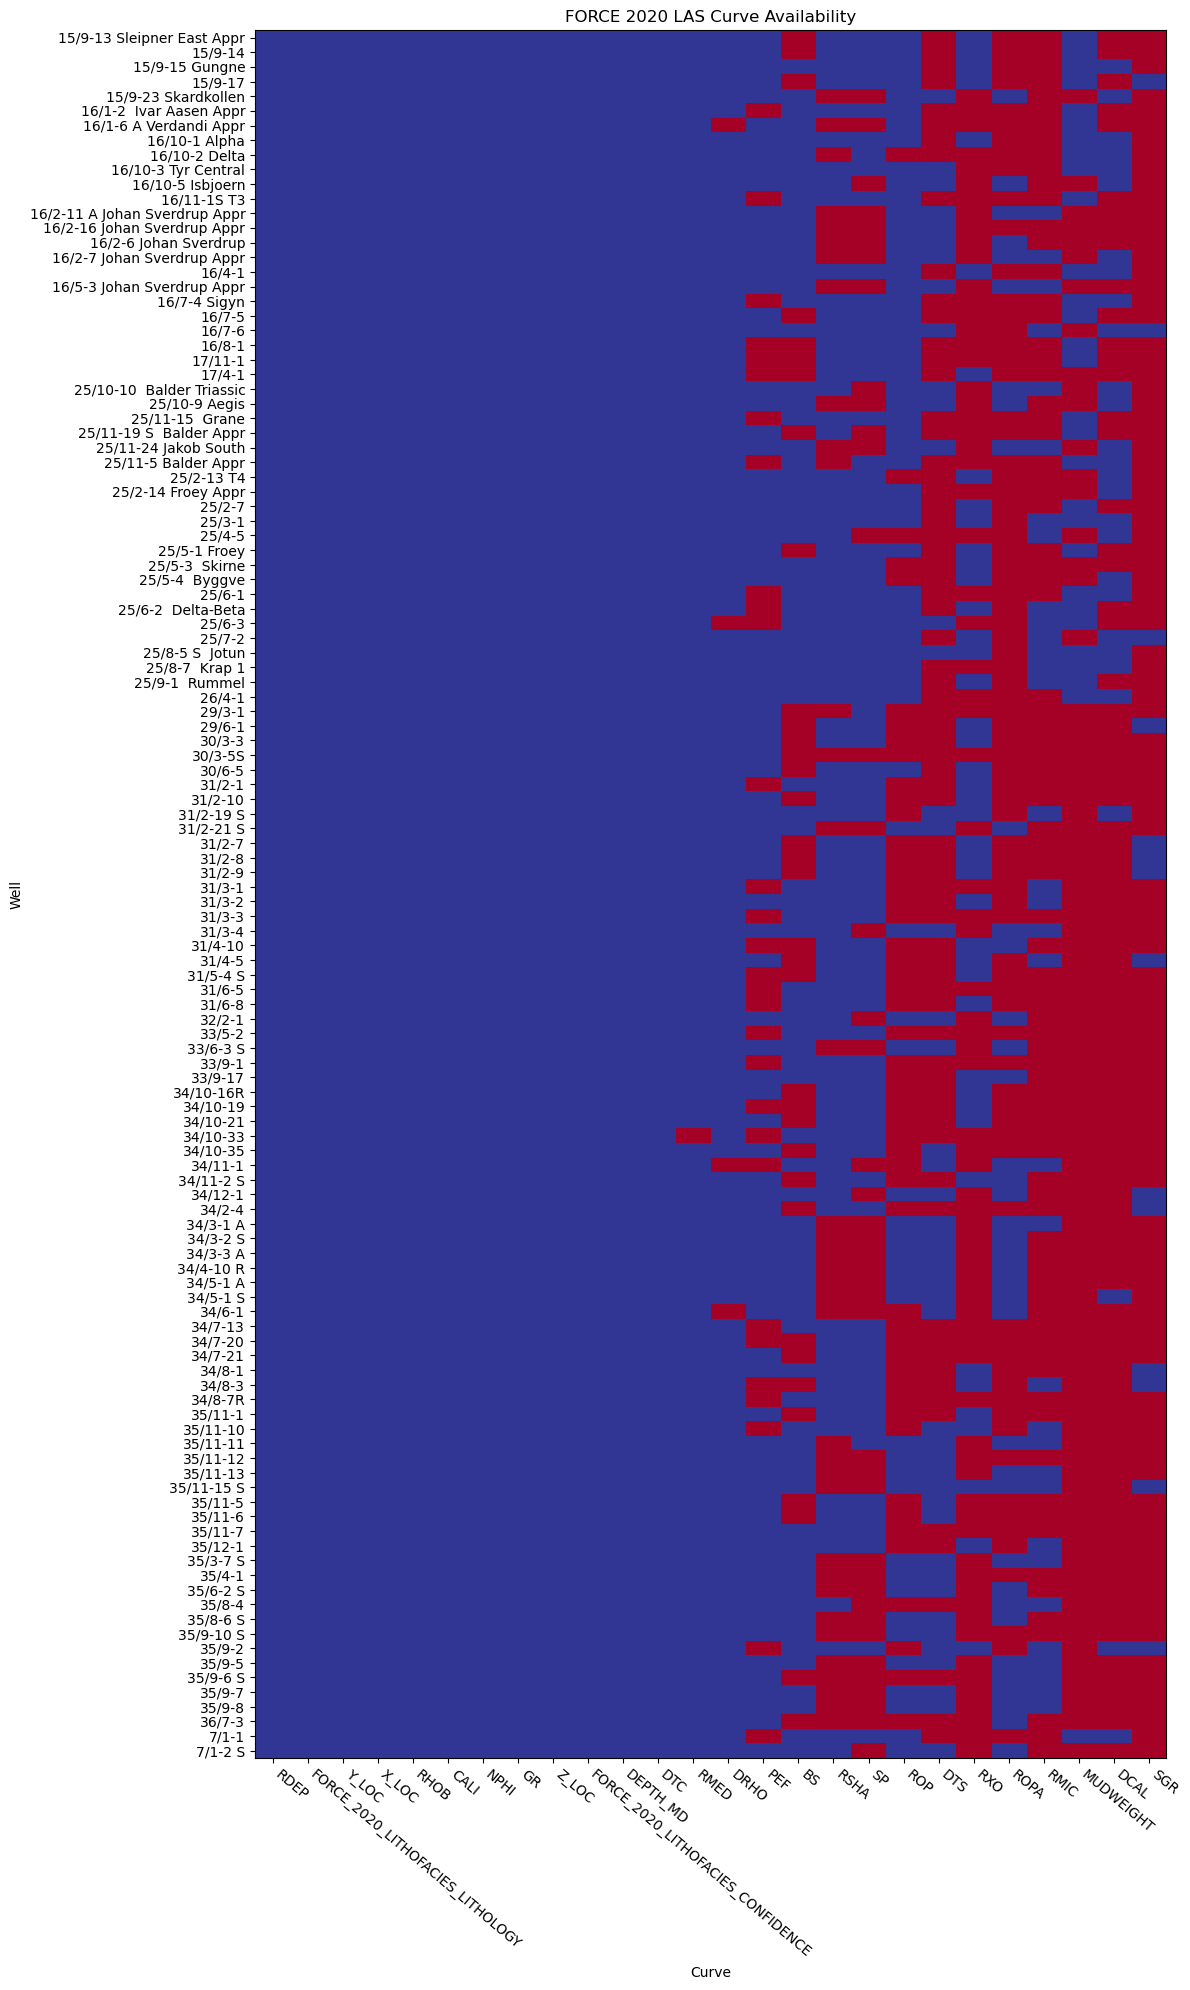

In [ ]:
### plot presence

import matplotlib.pyplot as plt

ordered_curves = (
    curve_presence
    .sum()
    .sort_values(ascending=False)
    .index
)

matrix = curve_presence[ordered_curves].astype(int)

fig, ax = plt.subplots(figsize=(12, 20))

ax.imshow(
    matrix,
    aspect="auto",
    interpolation="nearest",
    cmap="RdYlBu",
)

ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels(matrix.columns, rotation=90)

ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index)

ax.set_xlabel("Curve")
ax.set_ylabel("Well")
ax.set_title("FORCE 2020 LAS Curve Availability")


plt.xticks(rotation=-40, ha='left')
plt.tight_layout()
plt.show()